# 11.7 移动窗口函数

<Axes: >

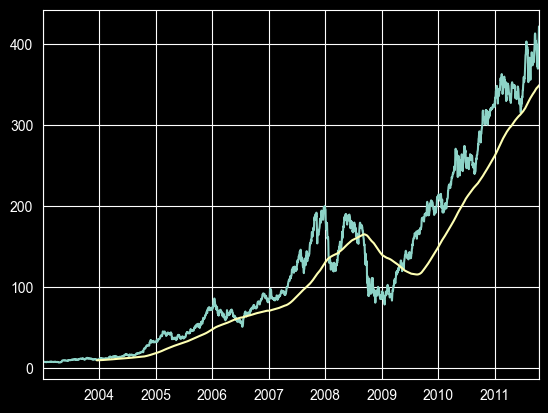

In [2]:
import pandas as pd
close_px_all = pd.read_csv('../examples/stock_px.csv',parse_dates=True,index_col=0)
close_px = close_px_all[['AAPL','MSFT','XOM']]
close_px = close_px.resample('B').ffill()  # 重采样为工作日频率
close_px['AAPL'].plot()
close_px['AAPL'].rolling(250).mean().plot()

In [3]:
# 默认情况下 rolling需要窗口内所有的值为非NA值 可以修改此行为
import numpy as np
s = pd.Series([1, 2, np.nan, 4, 5])
print(s.rolling(window=3, min_periods=2).mean())
# 0    NaN     ← 只有1个值
# 1    1.5     ← 有2个值(1,2)
# 2    1.5     ← 窗口[1,2,NaN]有2个
# 3    3.0     ← 窗口[2,NaN,4]有2个(2,4)
# 4    4.5     ← 窗口[NaN,4,5]有2个(4,5)

0    NaN
1    1.5
2    1.5
3    3.0
4    4.5
dtype: float64


<Axes: >

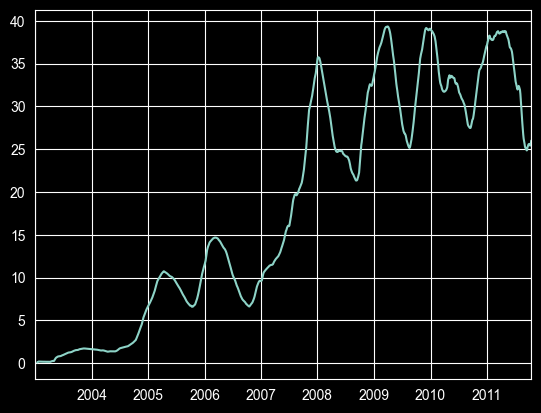

In [4]:
import matplotlib.pyplot as plt
plt.figure()
std250 = close_px['AAPL'].rolling(250, min_periods=10).std()
std250.plot()

<Axes: >

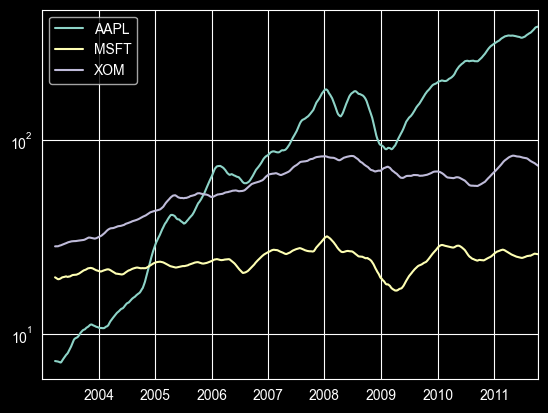

In [5]:
# 对DataFrame调用滚动窗口时会将转换应用到所有列上
close_px.rolling(60).mean().plot(logy=True)  # 以对数刻度显示

In [6]:
close_px.rolling('20D').mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


## 11.7.1 指数加权函数

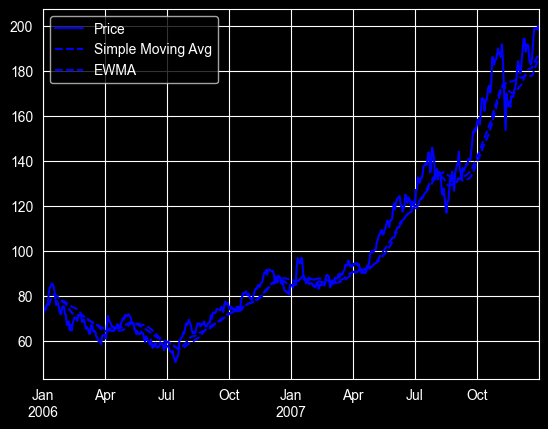

In [10]:
aapl_px = close_px['AAPL']['2006':'2007']
ma30 = aapl_px.rolling(30,min_periods=20).mean()
ewma30 = aapl_px.ewm(span=30).mean()  # 指数加权移动均值
aapl_px.plot(style='b-',label='Price')
ma30.plot(style='b--',label='Simple Moving Avg')
ewma30.plot(style='b--',label='EWMA')
plt.legend()

## 11.7.2 二元移动窗口函数

<Axes: >

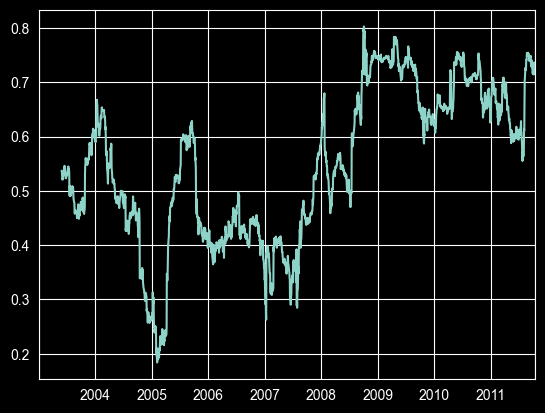

In [11]:
spx_px = close_px_all['SPX']
spx_rets = spx_px.pct_change()
returns = close_px.pct_change()
corr = returns['AAPL'].rolling(125, min_periods=100).corr(spx_rets)  # 苹果公司股票6个月收益与标普500指数收益的滚动相关系数
corr.plot()

<Axes: >

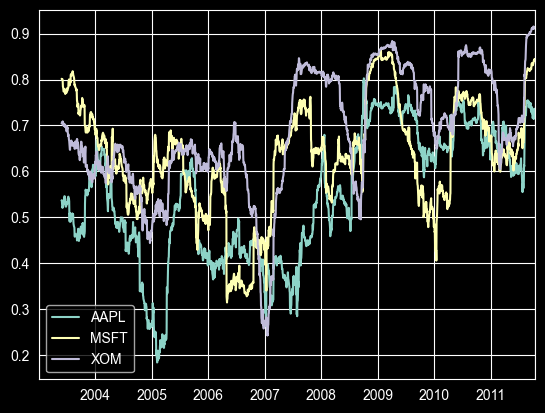

In [12]:
# 还可以对dataframe的每一列计算滚动相关系数
corr = returns.rolling(125, min_periods=100).corr(spx_rets)
corr.plot()

## 11.7.3 用户自定义的移动窗口函数

<Axes: >

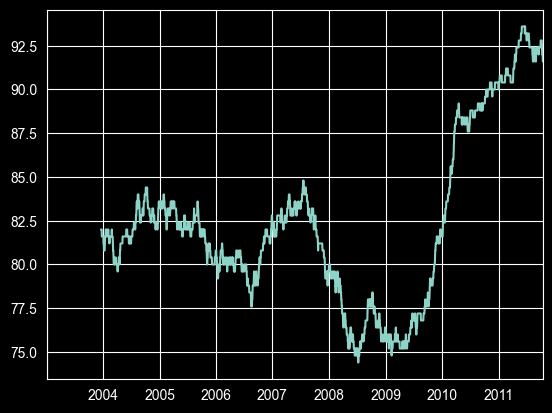

In [13]:
# 必须要是返回单值的函数
from scipy.stats import percentileofscore
score_at_2percent = lambda x: percentileofscore(x, 0.02)
result = returns['AAPL'].rolling(250).apply(score_at_2percent)
result.plot()

# End